In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [21]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [17]:
print(df['Age'].describe())

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [ ]:
# Clean missing ages by filling in the median values
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
# Clean missing values for Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [20]:
# Clean missing values for embarked by dropping them
df.dropna(subset=['Embarked'], inplace=True)

Text(0, 0.5, 'Number of Passengers')

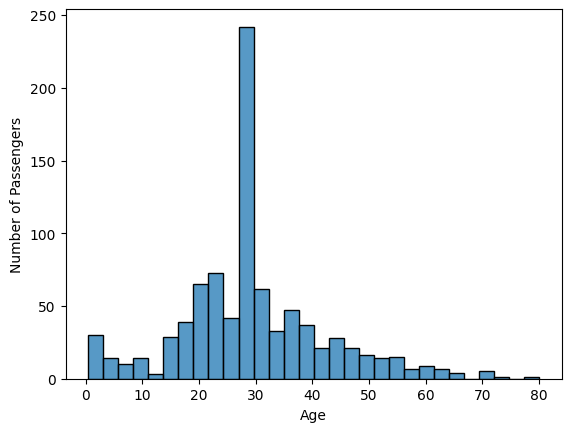

In [33]:
sns.histplot(df['Age'])
plt.ylabel('Number of Passengers')

Insight 1: The histoplot is fairly right-skewed meaning that majority of its passengers are in their early 20s to late 30s. Concluding that majority of the passengers are young adults 

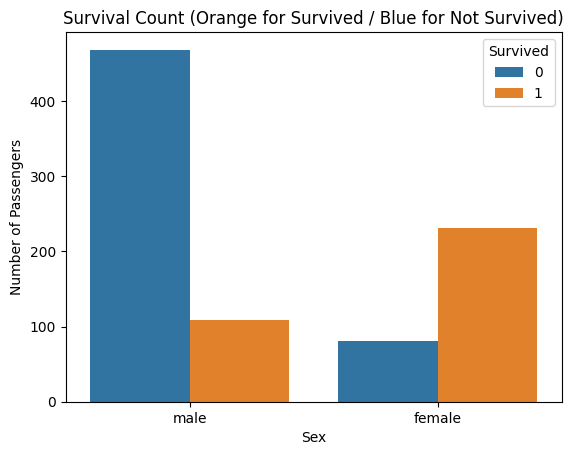

In [30]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count (Orange for Survived / Blue for Not Survived)')
plt.ylabel('Number of Passengers')
plt.show()


Insight 2: Females had a significantly higher survival rate than males. This supports the 'women and children first' rule.

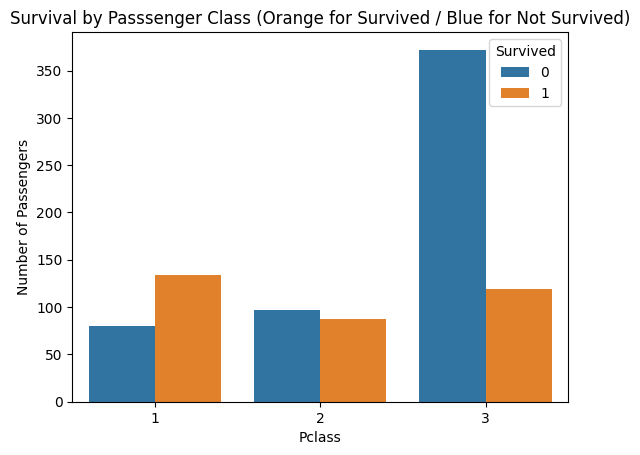

In [31]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.ylabel('Number of Passengers')
plt.title('Survival by Passsenger Class (Orange for Survived / Blue for Not Survived)')
plt.show()

Insight 3: 1st class passengers had the highest survival rate and 3rd class passengers had the lowest survival rate

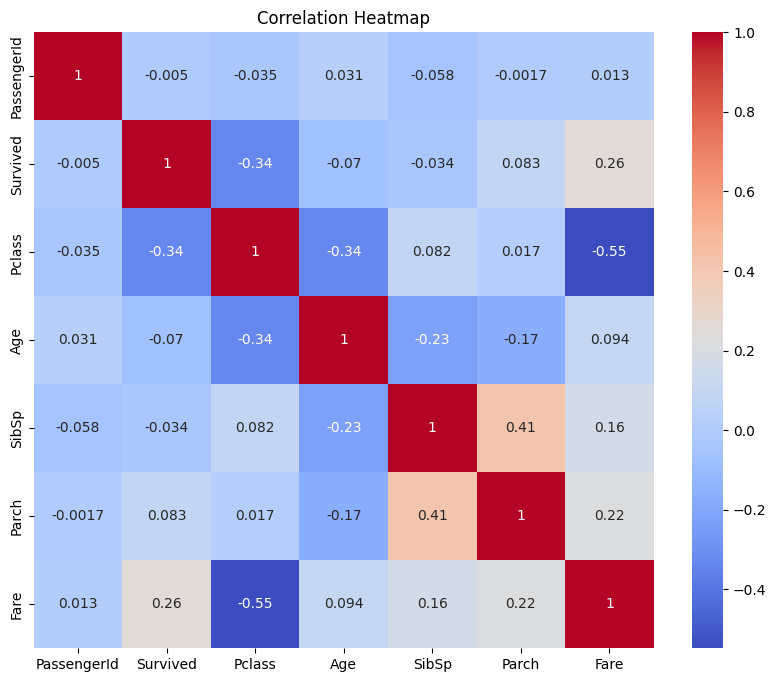

In [ ]:
# Extra visualization heatmap to show the correlation between all variables
num_df = df.select_dtypes(include="number")
plt.figure(figsize = (10, 8))
sns.heatmap(num_df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()